# CS 203 — Week 9 Lab: Reproducibility in Practice
**Software Tools and Techniques for AI | IIT Gandhinagar**

---

This lab covers the three-layer reproducibility stack from the lecture:

| Layer | Problem | Tool |
|-------|---------|------|
| The Machine | "Works on my laptop but not yours" | Docker |
| The Math | "Different results every run" | Seeds & determinism |
| The Memory | "Which of my 50 runs was the good one?" | Experiment tracking (TrackIO) |



---
## 0  Setup

In [1]:
!pip install trackio --quiet

  You can safely remove it manually.
  You can safely remove it manually.


In [2]:
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer, load_wine, load_digits
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("All imports successful ✓")

All imports successful ✓


---
## Part 1 — The Math: Seeds & Determinism

### 1.1  Witness the problem

Run the cell below **three times** without changing anything. Record what you observe.

In [3]:
X, y = load_breast_cancer(return_X_y=True)

# No random_state anywhere — pure chaos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)
print(f"Accuracy: {model.score(X_test, y_test):.4f}")

Accuracy: 0.9825


### 1.2  Quantify the variance

Run the unseeded code 20 times in a loop and collect all 20 accuracy values. Plot a histogram. Compute and print the mean and standard deviation.

mean ± std: 0.9657894736842104 ± 0.014912280701754396


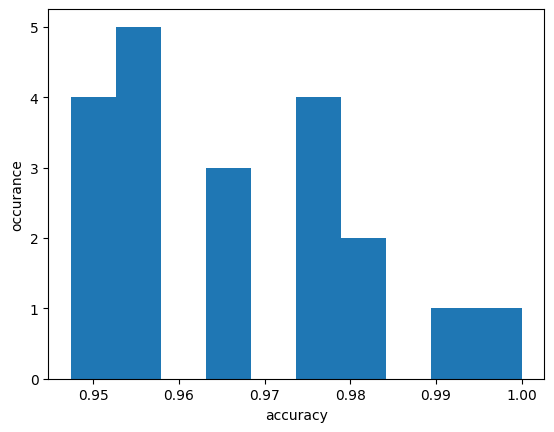

In [4]:
X, y = load_breast_cancer(return_X_y=True)
unseeded_scores = []

for _ in range(20):
    # YOUR CODE HERE
    # - split with no random_state
    # - train RandomForestClassifier(n_estimators=100) with no random_state
    # - append test accuracy to unseeded_scores
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    model = RandomForestClassifier(n_estimators=100)
    model.fit(X_train, y_train)
    unseeded_scores.append(model.score(X_test, y_test))

# YOUR CODE HERE — plot histogram and print mean ± std
print("mean ± std:", np.mean(unseeded_scores), '±', np.std(unseeded_scores))
plt.hist(unseeded_scores)
plt.xlabel("accuracy")
plt.ylabel("occurance")
plt.show()

### 1.3  Fix the Math — `random_state` everywhere

Now fix the code: add `random_state=42` to every call that accepts it. Run the cell 5 times and confirm you get **exactly the same number every time**.

In [5]:
X, y = load_breast_cancer(return_X_y=True)

# YOUR CODE HERE
# train_test_split with random_state=42
# RandomForestClassifier with random_state=42
# Print accuracy
for _ in range(5):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  model = RandomForestClassifier(n_estimators=100)
  model.fit(X_train, y_train)
  print(f"Accuracy: {model.score(X_test, y_test):.4f}")
# Run this cell 5 times — is it always the same?

Accuracy: 0.9649
Accuracy: 0.9649
Accuracy: 0.9649
Accuracy: 0.9649
Accuracy: 0.9649


### 1.4  Write a `set_seed` utility function

Write a function `set_seed(seed=42)` that seeds Python's `random`, NumPy, and (if available) PyTorch. Call it once at the top of a script before any other randomness.

In [6]:
def set_seed(seed=42):
    """
    Seed Python random, NumPy, and PyTorch (if installed).
    Call once at the top of any experiment script.
    """
    # YOUR CODE HERE
    # random.seed(seed)
    # np.random.seed(seed)
    # try torch seeds — wrap in try/except ImportError so it works without torch

    random.seed(seed)
    np.random.seed(seed)

    try:
      import torch
      torch.manual_seed(seed)
      torch.cuda.manual_seed(seed)
      torch.cuda.manual_seed_all(seed)
      torch.backends.cudnn.deterministic = True
      torch.backends.cudnn.benchmark = False
    except:
      pass


set_seed(42)
print("random:",  [random.randint(0, 100) for _ in range(5)])
print("numpy:",   np.random.randint(0, 100, 5))
# Run again — should print identical lines

random: [81, 14, 3, 94, 35]
numpy: [51 92 14 71 60]


### 1.5  Three sources of randomness in sklearn

Demonstrate that each of the three sources of ML randomness can vary independently. Use the Breast Cancer dataset.

For each source, run **unseeded** 10 times and compute std of resulting accuracy:
1. **Train/test split** — vary only the split, keep model fixed
2. **Model initialisation** — vary only the forest's `random_state`, keep split fixed
3. **Both unseeded** — vary both simultaneously

Print a table: Source | Mean accuracy | Std accuracy

In [7]:
X, y = load_breast_cancer(return_X_y=True)
N = 20

# 1. Vary only the split
split_scores = []
# YOUR CODE HERE — fix model random_state=42, vary split
for i in range(N):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  model = RandomForestClassifier(n_estimators=100, random_state=42)
  model.fit(X_train, y_train)
  split_scores.append(model.score(X_test, y_test))

# 2. Vary only the model
model_scores = []
# YOUR CODE HERE — fix split (random_state=42), vary model random_state
for i in range(N):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  model = RandomForestClassifier(n_estimators=100)
  model.fit(X_train, y_train)
  model_scores.append(model.score(X_test, y_test))

# 3. Vary both
both_scores = []
# YOUR CODE HERE — no random_state anywhere
for i in range(N):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  model = RandomForestClassifier(n_estimators=100)
  model.fit(X_train, y_train)
  both_scores.append(model.score(X_test, y_test))

# Print results table
print(f"{'Source':<25} {'Mean':>8} {'Std':>8}")
print('-' * 43)
for name, scores in [('Split only', split_scores),
                      ('Model only', model_scores),
                      ('Both', both_scores)]:
    print(f"{name:<25} {np.mean(scores):>8.4f} {np.std(scores):>8.4f}")

Source                        Mean      Std
-------------------------------------------
Split only                  0.9667   0.0153
Model only                  0.9632   0.0035
Both                        0.9636   0.0139


### 1.6  Multi-seed reporting (the honest way)

Full determinism isn't always achievable across machines (different OS, BLAS libraries). The professional approach: report **mean ± std across multiple seeds**.

Train a `GradientBoostingClassifier` on Wine using seeds 0–9. Report mean ± std of test accuracy. Then do the same for `RandomForestClassifier`. Print a two-row summary.

In [8]:
X, y = load_wine(return_X_y=True)

models_to_compare = {
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100),
    'RandomForest':     RandomForestClassifier(n_estimators=100),
}

# YOUR CODE HERE
# For each model, loop seeds 0–9:
#   - train_test_split(random_state=seed)
#   - fit model with random_state=seed
#   - record test accuracy
# Print: Model | Mean ± Std

for name, model in models_to_compare.items():
  scores = []
  for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    model = model
    model.random_state = i
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))
  print(f"{name} | {np.mean(scores):>8.4f} ± {np.std(scores):>8.4f}")

GradientBoosting |   0.9389 ±   0.0324
RandomForest |   0.9861 ±   0.0139


### 1.7  The KFold shuffle trap

Demonstrate that `KFold(shuffle=True)` **without** a `random_state` gives different fold assignments each call. Then fix it and show consistent CV scores.

In [9]:
X, y = load_breast_cancer(return_X_y=True)
model = RandomForestClassifier(n_estimators=50, random_state=42)

# WRONG — shuffles differently every time
scores_unseeded = []
for _ in range(5):
    kf = KFold(n_splits=5, shuffle=True)  # no random_state!
    scores_unseeded.append(cross_val_score(model, X, y, cv=kf).mean())
print("Unseeded CV scores:", [f"{s:.4f}" for s in scores_unseeded])

# YOUR CODE HERE
# Fix: add random_state=42 to KFold
# Repeat 5 times and print — should be identical each time
scores_seeded = []
# YOUR CODE HERE
for _ in range(5):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores_seeded.append(cross_val_score(model, X, y, cv=kf).mean())
print("Seeded CV scores:", [f"{s:.4f}" for s in scores_seeded])

Unseeded CV scores: ['0.9579', '0.9596', '0.9578', '0.9648', '0.9561']
Seeded CV scores: ['0.9578', '0.9578', '0.9578', '0.9578', '0.9578']


---
## Part 2 — The Memory: Experiment Tracking with TrackIO

### 2.1  First TrackIO run — the basics

Log a single training run for a `RandomForestClassifier` on Breast Cancer. Include in the `config`: model name, n_estimators, max_depth, random_state. Log: train_accuracy, test_accuracy, cv_accuracy (5-fold). Call `trackio.finish()`.

In [33]:
import trackio

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# YOUR CODE HERE
trackio.init(project="CS-203-lab9", name="first-run", config={"model": "RF", "n_estimators": 100, "max_depth": 10})
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)
trackio.log({"train_accuracy": model.score(X_train, y_train), "test_accuracy": model.score(X_test, y_test)})
trackio.finish()


print("Run logged ✓")

* Trackio project initialized: CS-203-lab9
* Trackio metrics logged to: C:\Users\ratho\.cache\huggingface\trackio
* Created new run: dainty-sunset-0


* Run finished. Uploading logs to Trackio (please wait...)
Run logged ✓


### 2.2  Training curve — log a metric at every step

Sweep `n_estimators` from 10 to 300 in steps of 10 for a `GradientBoostingClassifier` on Breast Cancer. At each step, log `n_estimators`, `train_accuracy`, and `test_accuracy` inside a single TrackIO run. The dashboard should show a smooth curve when you open it.

In [34]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# YOUR CODE HERE
trackio.init(project='cs203-week09', name='gb-curve', config={'lr': 0.1})
for n_est in range(10, 310, 10):
    model = GradientBoostingClassifier(n_estimators=n_est, random_state=42)
    model.fit(X_train, y_train)
    trackio.log({'n_estimators': n_est, 'train_accuracy': model.score(X_train, y_train), 'test_accuracy': model.score(X_test, y_test)})
trackio.finish()

* Trackio project initialized: cs203-week09
* Trackio metrics logged to: C:\Users\ratho\.cache\huggingface\trackio
* Created new run: jolly-valley-7


* Run finished. Uploading logs to Trackio (please wait...)


### 2.3  Compare hyperparameter configurations

Run the same sweep as 2.2 **three times**, once each for `learning_rate` in `[0.01, 0.1, 0.5]`. Each should be a **separate** TrackIO run named `gb-lr-0.01`, `gb-lr-0.1`, `gb-lr-0.5`. The dashboard will overlay all three curves.

In [35]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# YOUR CODE HERE
for lr in [0.01, 0.1, 0.5]:
    trackio.init(project='cs203-week09', name=f'gb-lr-{lr}', config={'learning_rate': lr})
    for n_est in range(10, 210, 10):
        model = GradientBoostingClassifier(n_estimators=n_est, learning_rate=lr, random_state=42)
        model.fit(X_train, y_train)
        trackio.log({'n_estimators': n_est, 'train_accuracy': model.score(X_train, y_train), 'test_accuracy': model.score(X_test, y_test)})
    trackio.finish()

* Created new run: kind-sky-8
* Run finished. Uploading logs to Trackio (please wait...)
* Created new run: lively-field-9
* Run finished. Uploading logs to Trackio (please wait...)
* Created new run: merry-cloud-10
* Run finished. Uploading logs to Trackio (please wait...)


### 2.4  Detect and alert on overfitting

Sweep `max_depth` from 1 to 30 on a `DecisionTreeClassifier` trained on Digits. At each step log `max_depth`, `train_accuracy`, `test_accuracy`, and `overfit_gap` (train - test). If the gap exceeds 0.10, call `trackio.alert(...)` with level `ERROR`.

Also plot the train/test curves from the logged data after the run.

In [36]:
X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

depths = []
train_accs = []
test_accs = []
gaps = []

# YOUR CODE HERE
trackio.init(project='cs203-week09', name='dt-overfit-sweep', config={'dataset': 'digits'})
for depth in range(1, 31):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    gap = train_acc - test_acc
    trackio.log({'max_depth': depth, 'train_accuracy': train_acc, 'test_accuracy': test_acc, 'overfit_gap': gap})
    if gap > 0.10:
        trackio.alert(title='Overfitting detected!', text=f'gap={gap:.2f} at depth={depth}',
                      level=trackio.AlertLevel.ERROR)
    depths.append(depth)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    gaps.append(gap)
trackio.finish()

# Plot train vs test accuracy as a function of depth
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accs, label='Train Accuracy')
plt.plot(depths, test_accs, label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs Max Depth')
plt.legend()
plt.show()

* Created new run: nice-star-11
[TRACKIO ERROR] Overfitting detected!: gap=0.10 at depth=9 (step 8)
[TRACKIO ERROR] Overfitting detected!: gap=0.12 at depth=10 (step 9)
[TRACKIO ERROR] Overfitting detected!: gap=0.14 at depth=11 (step 10)
[TRACKIO ERROR] Overfitting detected!: gap=0.15 at depth=12 (step 11)
[TRACKIO ERROR] Overfitting detected!: gap=0.16 at depth=13 (step 12)
[TRACKIO ERROR] Overfitting detected!: gap=0.16 at depth=14 (step 13)
[TRACKIO ERROR] Overfitting detected!: gap=0.16 at depth=15 (step 14)
[TRACKIO ERROR] Overfitting detected!: gap=0.16 at depth=16 (step 15)
[TRACKIO ERROR] Overfitting detected!: gap=0.16 at depth=17 (step 16)
[TRACKIO ERROR] Overfitting detected!: gap=0.16 at depth=18 (step 17)
[TRACKIO ERROR] Overfitting detected!: gap=0.16 at depth=19 (step 18)
[TRACKIO ERROR] Overfitting detected!: gap=0.16 at depth=20 (step 19)
[TRACKIO ERROR] Overfitting detected!: gap=0.16 at depth=21 (step 20)
[TRACKIO ERROR] Overfitting detected!: gap=0.16 at depth=22 (

### 2.5  Multi-model comparison run

Run a model comparison across **five** classifiers on the Wine dataset. Each model gets its own TrackIO run. Log: `train_accuracy`, `test_accuracy`, `cv_accuracy` (5-fold), `fit_time_s` (use `time.time()`). At the end, print a leaderboard sorted by `cv_accuracy`.

In [37]:
import time

X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_zoo = {
    'LogisticRegression':  LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree':        DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                 Pipeline([('scaler', StandardScaler()), ('svm', SVC(random_state=42))]),
}

leaderboard = []

for name, model in model_zoo.items():
    # YOUR CODE HERE
    # trackio.init, time the fit, log metrics, trackio.finish
    trackio.init(project='cs203-week09', name=name, config={'model': name})
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    cv_acc = cross_val_score(model, X_train, y_train, cv=5).mean()
    trackio.log({'train_accuracy': float(train_acc), 'test_accuracy': float(test_acc), 'cv_accuracy': float(cv_acc), 'fit_time_s': float(end_time - start_time)})
    trackio.finish()
    leaderboard.append({'model': name, 'cv_accuracy': float(cv_acc), 'test_accuracy': float(test_acc)})

# Print sorted leaderboard
df_lb = pd.DataFrame(leaderboard).sort_values('cv_accuracy', ascending=False)
print(df_lb.to_string(index=False))

* Created new run: proud-rain-12
* Run finished. Uploading logs to Trackio (please wait...)
* Created new run: quick-leaf-13
* Run finished. Uploading logs to Trackio (please wait...)
* Created new run: hugging-stone-14
* Run finished. Uploading logs to Trackio (please wait...)
* Created new run: silly-flower-15
* Run finished. Uploading logs to Trackio (please wait...)
* Created new run: tidy-bird-16
* Run finished. Uploading logs to Trackio (please wait...)
             model  cv_accuracy  test_accuracy
      RandomForest     0.978571       1.000000
               SVM     0.971921       1.000000
LogisticRegression     0.950493       0.972222
  GradientBoosting     0.922167       0.944444
      DecisionTree     0.915271       0.944444


### 2.6  Launch the TrackIO dashboard

The cell below launches the dashboard in a background thread. Open the printed URL in your browser. Verify you can see all the runs from 2.1–2.5.

In [38]:
# This opens the local Gradio-based dashboard
# In Colab the link will be a public tunnel URL
import subprocess
subprocess.Popen(['python', '-m', 'trackio', 'show', '--project', 'cs203-week09'])
print("Dashboard starting... open the URL printed above in your browser.")
print("(In Colab it may take ~10 seconds to appear)")

Dashboard starting... open the URL printed above in your browser.
(In Colab it may take ~10 seconds to appear)


---
## Part 3 — The Machine: Docker Fundamentals

> **These sections run on your local machine, not in Colab.**  
> Each task gives you exact file content to create locally, then a terminal command to run.



### 3.1  Hello Docker — your first container

**On your local machine**, create a directory `lab09/1-hello/` with the following two files.

**`hello.py`**
```python
import sys, platform
print(f"Python: {sys.version}")
print(f"OS: {platform.system()} {platform.release()}")
print(f"Architecture: {platform.machine()}")
print("Hello from inside Docker! 🐳")
```

**`Dockerfile`** — complete the missing lines below:

In [39]:
dockerfile_hello = """
FROM python:3.10-slim
WORKDIR /app
COPY hello.py .
CMD ["python", "hello.py"]
"""

print(dockerfile_hello)
print()
print("Terminal commands to run:")
print("  cd lab09/1-hello/")
print("  docker build -t hello-docker .")
print("  docker run hello-docker")
print()
print("Expected: OS prints 'Linux' even if you're on a Mac or Windows!")


FROM python:3.10-slim
WORKDIR /app
COPY hello.py .
CMD ["python", "hello.py"]


Terminal commands to run:
  cd lab09/1-hello/
  docker build -t hello-docker .
  docker run hello-docker

Expected: OS prints 'Linux' even if you're on a Mac or Windows!


**After running the commands**, answer here:
- What Python version did Docker print?
- What OS did it report? Was it the same as your host OS?
- Run `docker run -it hello-docker bash` — what prompt do you see?
- Inside that shell, run `python --version`. Exit with `exit`.

1. 3.10.20
2. Linux 5.15.167.4-microsoft-standard-WSL2
3. root@a7aed86ded99:/app#
4. Python 3.10.20

### 3.2  Dockerfile layer caching — understand the order

Below are two Dockerfile variants for the same ML training script. One is **well-ordered** (cache-friendly), the other is **poorly-ordered** (busts the cache on every code change).

Identify which is which and explain **why** the order of `COPY` and `RUN pip install` matters.

In [40]:
dockerfile_A = """
FROM python:3.10-slim
WORKDIR /app
COPY . .                        # copy everything first
RUN pip install -r requirements.txt
CMD ["python", "train.py"]
"""

dockerfile_B = """
FROM python:3.10-slim
WORKDIR /app
COPY requirements.txt .         # only requirements first
RUN pip install -r requirements.txt
COPY . .                        # then copy code
CMD ["python", "train.py"]
"""

# YOUR CODE HERE
# Print which is cache-friendly and explain in a comment:
#   When only train.py changes (requirements unchanged), which Dockerfile
#   will skip the slow `pip install` step? Why?

print("Dockerfile A is: cache-busting")   # YOUR CODE HERE — 'cache-friendly' or 'cache-busting'
print("Dockerfile B is: cache-friendly")
print()
print("Explanation:")
print("dockerfile B copy requirements and install dependencies before copying the rest of the code. So if only train.py changes, Docker can use the cached layer for pip install and skip it, making it faster. Dockerfile A copies everything first, so any change to train.py will invalidate the cache for the pip install step, causing it to run again.")

Dockerfile A is: cache-busting
Dockerfile B is: cache-friendly

Explanation:
dockerfile B copy requirements and install dependencies before copying the rest of the code. So if only train.py changes, Docker can use the cached layer for pip install and skip it, making it faster. Dockerfile A copies everything first, so any change to train.py will invalidate the cache for the pip install step, causing it to run again.


### 3.3  Reproducible ML training image

Create `lab09/2-reproducible/` with three files.

**`requirements.txt`** — pin exact versions:

In [41]:
# Run this in Colab to see your current versions
import sklearn, numpy, pandas
print(f"scikit-learn=={sklearn.__version__}")
print(f"numpy=={numpy.__version__}")
print(f"pandas=={pandas.__version__}")

# Copy this output into your requirements.txt
with open('./lab09/2-reproducible/requirements.txt', 'w') as f:
    f.write(f"scikit-learn=={sklearn.__version__}\n")
    f.write(f"numpy=={numpy.__version__}\n")
    f.write(f"pandas=={pandas.__version__}\n")

scikit-learn==1.8.0
numpy==2.4.2
pandas==2.3.3


In [42]:
train_py = '''
# 1. Import sklearn, numpy
import numpy as np
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# 2. set random_state=42 everywhere
np.random.seed(42)

# 3. Load breast_cancer dataset
X, y = load_breast_cancer(return_X_y=True)

# 4. Train-test split (test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train RandomForestClassifier(n_estimators=100, random_state=42)
model = sklearn.ensemble.RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Print accuracy rounded to 4 decimal places
print(f"Accuracy: {model.score(X_test, y_test):.4f}")

# 7. Print sklearn version used
print(f"sklearn version: {sklearn.__version__}")
'''

print("Write this to lab09/2-reproducible/train.py:")
with open('./lab09/2-reproducible/train.py', 'w') as f:
    f.write(train_py)
print(train_py)

Write this to lab09/2-reproducible/train.py:

# 1. Import sklearn, numpy
import numpy as np
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# 2. set random_state=42 everywhere
np.random.seed(42)

# 3. Load breast_cancer dataset
X, y = load_breast_cancer(return_X_y=True)

# 4. Train-test split (test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train RandomForestClassifier(n_estimators=100, random_state=42)
model = sklearn.ensemble.RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Print accuracy rounded to 4 decimal places
print(f"Accuracy: {model.score(X_test, y_test):.4f}")

# 7. Print sklearn version used
print(f"sklearn version: {sklearn.__version__}")



In [44]:
dockerfile_repro = """
FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install -r requirements.txt
COPY . .
CMD ["python", "train.py"]
"""

with open('./lab09/2-reproducible/Dockerfile', 'w') as f:
    f.write(dockerfile_repro)

print("Terminal commands:")
print("  cd lab09/2-reproducible/")
print("  docker build -t train-repro .")
print("  docker run train-repro    # run twice — should be identical!")
print("  docker run train-repro")

Terminal commands:
  cd lab09/2-reproducible/
  docker build -t train-repro .
  docker run train-repro    # run twice — should be identical!
  docker run train-repro


---
## Part 4 — Docker Volumes, Ports, and Environment Variables

### 4.1  Volumes — containers have amnesia

Create `lab09/3-volumes/`. Write a training script that saves a trained model to `/app/outputs/model.pkl` and a log to `/app/outputs/training_log.txt`.

In [46]:
train_with_save_py = '''
# train_save.py — trains and saves model + log to /app/outputs/
import pickle, os
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

os.makedirs('/app/outputs', exist_ok=True)

# YOUR CODE HERE
# 1. Load breast_cancer, split (random_state=42)
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train RandomForestClassifier(n_estimators=100, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Save model to /app/outputs/model.pkl using pickle
with open('/app/outputs/model.pkl', 'wb') as f:
    pickle.dump(model, f)   

# 4. Write a log file /app/outputs/training_log.txt containing:
from datetime import datetime
accuracy = model.score(X_test, y_test)
sklearn_version = sklearn.__version__
timestamp = datetime.now().isoformat()
with open('/app/outputs/training_log.txt', 'w') as f:
    f.write(f"accuracy: {accuracy:.4f}")
    f.write(f"sklearn version: {sklearn_version}")
    f.write(f"timestamp: {timestamp}")
    
# 5. Print "Model and log saved to /app/outputs/"
print("Model and log saved to /app/outputs/")
'''
with open('./lab09/3-volumes/train_save.py', 'w') as f:
    f.write(train_with_save_py)
print(train_with_save_py)

print()
print("Dockerfile is same as 3.4 but CMD runs train_save.py")
print()
print("Terminal commands to run:")
print("  cd lab09/3-volumes/")
print("  docker build -t train-save .")
print()
print("  # Without volume — files lost:")
print("  docker run train-save")
print("  ls outputs/   # → No such file!")
print()
print("  # With volume — files survive:")
print("  mkdir -p outputs")
print("  docker run -v $(pwd)/outputs:/app/outputs train-save")
print("  ls outputs/   # → model.pkl  training_log.txt")
print("  cat outputs/training_log.txt")


# train_save.py — trains and saves model + log to /app/outputs/
import pickle, os
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

os.makedirs('/app/outputs', exist_ok=True)

# YOUR CODE HERE
# 1. Load breast_cancer, split (random_state=42)
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train RandomForestClassifier(n_estimators=100, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Save model to /app/outputs/model.pkl using pickle
with open('/app/outputs/model.pkl', 'wb') as f:
    pickle.dump(model, f)   

# 4. Write a log file /app/outputs/training_log.txt containing:
from datetime import datetime
accuracy = model.score(X_test, y_test)
sklearn_version = sklearn.__version__
timestamp = datetime.now().isoformat()
with open('/

### 4.2  Port mapping — expose a web app

Create `lab09/4-webapp/`. Write a minimal Gradio app that classifies Breast Cancer data and exposes it on port 7860.

In [48]:
webapp_py = '''
# app.py — simple Gradio ML demo
import gradio as gr
import pickle
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Train at startup (in production you'd load a saved model)
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
feature_names = load_breast_cancer().feature_names.tolist()

def predict(*args):
    # YOUR CODE HERE
    # args is a tuple of 30 floats (one per feature)
    # Return a string: "Malignant" or "Benign" with the probability
    input_array = np.array(args).reshape(1, -1)
    proba = model.predict_proba(input_array)[0]
    pred = model.predict(input_array)[0]
    label = "Malignant" if pred == 0 else "Benign"
    return f"{label} (proba: {proba[pred]:.2f})"

# Build Gradio interface with 5 key features (radius_mean, texture_mean,
# perimeter_mean, area_mean, smoothness_mean) as Number inputs
# Use gr.Interface or gr.Blocks
# YOUR CODE HERE
inputs = [gr.Number(label=feature) for feature in ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']]
interface = gr.Interface(fn=predict, inputs=inputs, outputs="text", title="Breast Cancer Prediction", description="Enter the values of 5 features to predict if the tumor is malignant or benign.")
interface.launch(server_name="0.0.0.0")

# IMPORTANT for Docker:
demo.launch(server_name="0.0.0.0", server_port=7860)
'''
with open('./lab09/4-webapp/app.py', 'w') as f:
    f.write(webapp_py)
print(webapp_py)

requirements_webapp = """
gradio
scikit-learn==1.8.0
numpy==2.4.2
"""
with open('./lab09/4-webapp/requirements.txt', 'w') as f:
    f.write(requirements_webapp)

dockerfile_webapp = """
FROM python:3.10-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install -r requirements.txt
COPY app.py .
ENV GRADIO_SERVER_NAME="0.0.0.0"
EXPOSE 7860
CMD ["python", "app.py"]
"""

with open("./lab09/4-webapp/Dockerfile", 'w') as f:
    f.write(dockerfile_webapp)
print("\nDockerfile:")
print(dockerfile_webapp)
print()
print("Terminal commands:")
print("  cd lab09/4-webapp/")
print("  docker build -t cancer-app .")
print("  docker run -p 7861:7860 cancer-app")
print("  # Open http://localhost:7861 in your browser")


# app.py — simple Gradio ML demo
import gradio as gr
import pickle
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Train at startup (in production you'd load a saved model)
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
feature_names = load_breast_cancer().feature_names.tolist()

def predict(*args):
    # YOUR CODE HERE
    # args is a tuple of 30 floats (one per feature)
    # Return a string: "Malignant" or "Benign" with the probability
    input_array = np.array(args).reshape(1, -1)
    proba = model.predict_proba(input_array)[0]
    pred = model.predict(input_array)[0]
    label = "Malignant" if pred == 0 else "Benign"
    return f"{label} (proba: {proba[pred]:.2f})"

# Build Gra

### 4.3  Environment variables — same image, different behaviour

Modify the training script to read `MODEL_TYPE` and `N_ESTIMATORS` from environment variables using `os.environ.get()`. Default: `rf` and `100`.

Write the code in the cell, then show the three `docker run` commands that exercise all three combinations.

In [1]:
env_train_py = '''
# env_train.py — reads MODEL_TYPE and N_ESTIMATORS from environment
import os
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

MODEL_TYPE   = os.environ.get('MODEL_TYPE',   'rf')    # default: Random Forest
N_ESTIMATORS = int(os.environ.get('N_ESTIMATORS', '100'))  # default: 100

# YOUR CODE HERE
# 1. Print f"Model: {MODEL_TYPE}, N_estimators: {N_ESTIMATORS}"
print(f"Model: {MODEL_TYPE}, N_estimators: {N_ESTIMATORS}")

# 2. Load wine, split (random_state=42)
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Pick model based on MODEL_TYPE:
if MODEL_TYPE == 'rf':
    model = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=42)
elif MODEL_TYPE == 'gb':
    model = GradientBoostingClassifier(n_estimators=N_ESTIMATORS, random_state=42)
elif MODEL_TYPE == 'svm':
    model = Pipeline([('scaler', StandardScaler()), ('svm', SVC(random_state=42))])
else:
    raise ValueError(f"Unknown model: {MODEL_TYPE}")

# 4. Fit and print accuracy
model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.2f}")
'''
with open('./lab09/5-envdemo/env_train.py', 'w') as f:
    f.write(env_train_py)
print(env_train_py)

dockerfile = """"
FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install -r requirements.txt
COPY . .
ENV GRADIO_SERVER_NAME=0.0.0.0
"""

with open('./lab09/5-envdemo/Dockerfile', 'w') as f:
    f.write(dockerfile)
    
requirements_envdemo = """
scikit-learn==1.8.0
numpy==2.4.2
"""
with open('./lab09/5-envdemo/requirements.txt', 'w') as f:
    f.write(requirements_envdemo)

print()
print("After building the image (docker build -t env-demo .), run:")
print()
print("  # Default (Random Forest, 100 trees):")
print("  docker run env-demo")
print()
print("  # YOUR CODE HERE — docker run command for SVM:")
print("  docker run -e MODEL_TYPE=svm env-demo")
print()
print("  # YOUR CODE HERE — docker run command for Gradient Boosting with 200 trees:")
print("  docker run -e MODEL_TYPE=gb -e N_ESTIMATORS=200 env-demo")


# env_train.py — reads MODEL_TYPE and N_ESTIMATORS from environment
import os
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

MODEL_TYPE   = os.environ.get('MODEL_TYPE',   'rf')    # default: Random Forest
N_ESTIMATORS = int(os.environ.get('N_ESTIMATORS', '100'))  # default: 100

# YOUR CODE HERE
# 1. Print f"Model: {MODEL_TYPE}, N_estimators: {N_ESTIMATORS}"
print(f"Model: {MODEL_TYPE}, N_estimators: {N_ESTIMATORS}")

# 2. Load wine, split (random_state=42)
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Pick model based on MODEL_TYPE:
if MODEL_TYPE == 'rf':
    model = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=42)
elif MODEL_TYPE == 'gb':
    mod

---
## Part 5 — Capstone: A Fully Reproducible ML Project

Build a complete, reproducible ML project from scratch in `lab09/capstone/`. It must satisfy all four layers of the reproducibility stack.

### 5.1  Project structure

Your directory must look like this:
```
lab09/capstone/
├── Dockerfile
├── requirements.txt       ← pinned versions
├── train.py               ← seeded training + trackio logging
├── predict.py             ← loads saved model and scores one sample
└── outputs/               ← created at runtime by Docker volume
```

Write the contents of each file in the cells below, then assemble them locally and run.

In [3]:
requirements_capstone = """
scikit-learn==1.8.0
numpy==2.4.2
pandas==2.3.3
trackio==0.20.0
"""
with open('./lab09/capstone/requirements.txt', 'w') as f:
    f.write(requirements_capstone)
print(requirements_capstone)


scikit-learn==1.8.0
numpy==2.4.2
pandas==2.3.3
trackio==0.20.0



In [11]:
train_capstone_py = '''
# Requirements:
#  - set_seed(42) called at the top
#  - random_state=42 in all sklearn calls
#  - Train on Digits dataset, Random Forest classifier
#  - Log the run with trackio (init, log, finish)
#     config must include: model, n_estimators, max_depth, random_state, dataset
#     logged metrics: train_accuracy, test_accuracy, n_classes, n_features
#  - Save trained model to /app/outputs/model.pkl
#  - Save a metadata JSON to /app/outputs/meta.json:
#     {"accuracy": ..., "sklearn_version": ..., "seed": 42, "timestamp": ...}
#  - Print a summary at the end

# YOUR CODE HERE
import os
import numpy as np
import sklearn
import pickle
import trackio
from datetime import datetime
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import json

def set_seed(seed=42):
    np.random.seed(seed)

set_seed(42)

X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

trackio.init(project='cs203-capstone', name='train-digits', config={'model': 'RandomForest', 'n_estimators': 100, 'max_depth': 10, 'random_state': 42, 'dataset': 'digits'})
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

n_classes = len(np.unique(y))
n_features = X.shape[1]
trackio.log({'train_accuracy': float(train_acc), 'test_accuracy': float(test_acc), 'n_classes': n_classes, 'n_features': n_features})

os.makedirs('/app/outputs', exist_ok=True)
with open('/app/outputs/model.pkl', 'wb') as f:
    pickle.dump(model, f)
    
meta = {
    'accuracy': test_acc,
    'sklearn_version': sklearn.__version__,
    'seed': 42,
    'timestamp': datetime.now().isoformat()
}

with open('/app/outputs/meta.json', 'w') as f:
    json.dump(meta, f, indent=4)
    
print(f"Training complete! Test accuracy: {test_acc:.4f}, model saved to /app/outputs/model.pkl, metadata saved to /app/outputs/meta.json")
trackio.finish()
'''

with open('./lab09/capstone/train.py', 'w') as f:
    f.write(train_capstone_py)
print(train_capstone_py)


# Requirements:
#  - set_seed(42) called at the top
#  - random_state=42 in all sklearn calls
#  - Train on Digits dataset, Random Forest classifier
#  - Log the run with trackio (init, log, finish)
#     config must include: model, n_estimators, max_depth, random_state, dataset
#     logged metrics: train_accuracy, test_accuracy, n_classes, n_features
#  - Save trained model to /app/outputs/model.pkl
#  - Save a metadata JSON to /app/outputs/meta.json:
#     {"accuracy": ..., "sklearn_version": ..., "seed": 42, "timestamp": ...}
#  - Print a summary at the end

# YOUR CODE HERE
import os
import numpy as np
import sklearn
import pickle
import trackio
from datetime import datetime
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import json

def set_seed(seed=42):
    np.random.seed(seed)

set_seed(42)

X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(

In [8]:
predict_capstone_py = '''
# Requirements:
#  - Load /app/outputs/model.pkl with pickle
#  - Load Digits dataset, take the first test sample
#  - Print: predicted class, true class, and whether they match
#  - Also read /app/outputs/meta.json and print the accuracy it was trained with

# YOUR CODE HERE
import os
import pickle
import json
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
# Load model
with open('/app/outputs/model.pkl', 'rb') as f:
    model = pickle.load(f)
# Load test sample
X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
test_sample = X_test[0].reshape(1, -1)
true_class = y_test[0]
# Predict
pred_class = model.predict(test_sample)[0]
# Load metadata
with open('/app/outputs/meta.json', 'r') as f:
    meta = json.load(f)
accuracy = meta.get('accuracy', 'N/A')
# Print results
print(f"Predicted class: {pred_class}")
print(f"True class: {true_class}")
print(f"Match: {'Yes' if pred_class == true_class else 'No'}")
print(f"Model was trained with accuracy: {accuracy:.4f}")
'''

with open('./lab09/capstone/predict.py', 'w') as f:
    f.write(predict_capstone_py)
print(predict_capstone_py)


# Requirements:
#  - Load /app/outputs/model.pkl with pickle
#  - Load Digits dataset, take the first test sample
#  - Print: predicted class, true class, and whether they match
#  - Also read /app/outputs/meta.json and print the accuracy it was trained with

# YOUR CODE HERE
import os
import pickle
import json
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
# Load model
with open('/app/outputs/model.pkl', 'rb') as f:
    model = pickle.load(f)
# Load test sample
X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
test_sample = X_test[0].reshape(1, -1)
true_class = y_test[0]
# Predict
pred_class = model.predict(test_sample)[0]
# Load metadata
with open('/app/outputs/meta.json', 'r') as f:
    meta = json.load(f)
accuracy = meta.get('accuracy', 'N/A')
# Print results
print(f"Predicted class: {pred_class}")
print(f"True class: {true_class}")
print(f"Match: {'Yes' if pr

In [10]:
dockerfile_capstone = """
FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install -r requirements.txt
COPY . .
CMD ["sh", "-c", "python train.py && python predict.py"]
"""

with open('./lab09/capstone/Dockerfile', 'w') as f:
    f.write(dockerfile_capstone)
print(dockerfile_capstone)


FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install -r requirements.txt
COPY . .
CMD ["sh", "-c", "python train.py && python predict.py"]



In [12]:
# Terminal commands checklist
capstone_commands = """
# ---- Run this sequence in your terminal ----

cd lab09/capstone/

# 1. Build the image
docker build -t cs203-capstone .

# 2. Train — save outputs to host via volume
mkdir -p outputs
docker run -v $(pwd)/outputs:/app/outputs cs203-capstone

# 3. Verify the outputs exist on your host machine
ls outputs/
cat outputs/meta.json

# 4. Run predict in the same container (using outputs from step 2)
docker run -v $(pwd)/outputs:/app/outputs cs203-capstone python predict.py

# 5. Run training AGAIN — should produce identical accuracy
docker run -v $(pwd)/outputs:/app/outputs cs203-capstone

# 6. Shell into the container and inspect manually
docker run -it -v $(pwd)/outputs:/app/outputs cs203-capstone bash
# Inside: ls /app/outputs, cat /app/outputs/meta.json, python predict.py, exit
"""

print(capstone_commands)


# ---- Run this sequence in your terminal ----

cd lab09/capstone/

# 1. Build the image
docker build -t cs203-capstone .

# 2. Train — save outputs to host via volume
mkdir -p outputs
docker run -v $(pwd)/outputs:/app/outputs cs203-capstone

# 3. Verify the outputs exist on your host machine
ls outputs/
cat outputs/meta.json

# 4. Run predict in the same container (using outputs from step 2)
docker run -v $(pwd)/outputs:/app/outputs cs203-capstone python predict.py

# 5. Run training AGAIN — should produce identical accuracy
docker run -v $(pwd)/outputs:/app/outputs cs203-capstone

# 6. Shell into the container and inspect manually
docker run -it -v $(pwd)/outputs:/app/outputs cs203-capstone bash
# Inside: ls /app/outputs, cat /app/outputs/meta.json, python predict.py, exit

